<a href="https://colab.research.google.com/github/niyamaryam/Image-classification-using-CNN-model/blob/main/dogs_v_cats_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow numpy matplotlib


In [10]:
#install kaggle
!pip install -q kaggle

In [11]:
from  google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"niyamaryam","key":"cad1e556ada7d2c3000afdb9b78730bc"}'}

**Create a Kaggle Folder and Copy the JSON File**

In [13]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [15]:
!chmod 600 ~/.kaggle/kaggle.json

**Download dataset from kaggle**

In [19]:
! kaggle datasets download salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
 99% 1.06G/1.06G [00:12<00:00, 194MB/s]
100% 1.06G/1.06G [00:12<00:00, 94.6MB/s]


In [ ]:
! unzip dogs-vs-cats.zip

**Import libraries**

In [98]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

**Load and Prepare the Data**

In [105]:
# Image data augmentation and loading
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    '/content/dogs_vs_cats/train',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    '/content/dogs_vs_cats/train',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


**Build the CNN Model**

In [106]:
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    BatchNormalization(),  # Normalize activations after Conv layer
    MaxPooling2D((2, 2)),
    Dropout(0.25),          # Dropout to reduce overfitting

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten and Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])


**Compile the Model**

In [107]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

**Train the Model**

In [108]:
history = model.fit(train_gen, epochs=10, validation_data=val_gen)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 103ms/step - accuracy: 0.5873 - loss: 0.8481 - val_accuracy: 0.6263 - val_loss: 0.6500
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 98ms/step - accuracy: 0.6643 - loss: 0.6103 - val_accuracy: 0.7210 - val_loss: 0.5466
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 100ms/step - accuracy: 0.7353 - loss: 0.5278 - val_accuracy: 0.6833 - val_loss: 0.6057
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.7677 - loss: 0.4771 - val_accuracy: 0.7038 - val_loss: 0.5612
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.8132 - loss: 0.4114 - val_accuracy: 0.7663 - val_loss: 0.4779
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.8673 - loss: 0.3292 - val_accuracy: 0.7545 - val_loss: 0.5161
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.8945 - loss: 0.2615 - val_accuracy: 0.7657 - val_loss: 0.5427
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.9137 - loss: 0.2200 - val_ac

**Evaluate the Model**

In [123]:
loss, acc = model.evaluate(val_gen)
print(f"Test Accuracy: {acc * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.7871 - loss: 0.5844
Test Accuracy: 78.97%


**Plotting the graph**

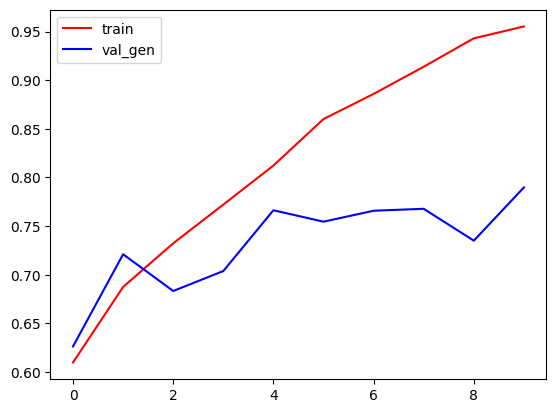

In [109]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val_gen')
plt.legend()
plt.show()

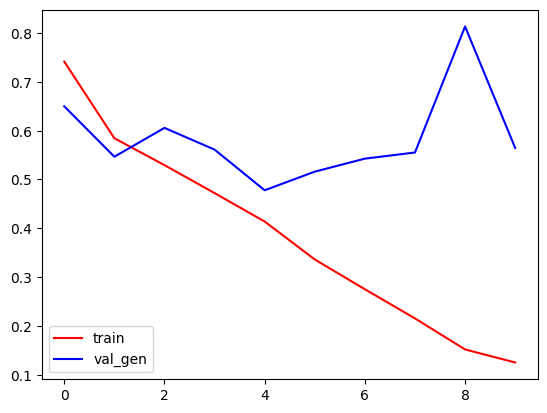

In [110]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val_gen')
plt.legend()
plt.show()

**Predict and Visualize an Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


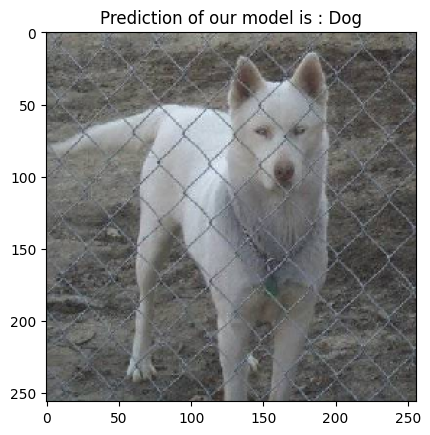

In [122]:
# Randomly select an image to predict
idx = random.randint(0, len(val_gen))
img, label = val_gen[idx]

# Predict the class of the image
y_pred = model.predict(img[0].reshape(1, 256, 256, 3))
pred_label = 'Dog' if y_pred > 0.5 else 'Cat'

# Display the image and prediction
plt.imshow(img[0])
plt.title(f"Prediction of our model is : {pred_label}")
plt.show()
